In [27]:
import pandas as pd
import numpy as np
from plotnine import *
from pyreadr import read_r

# Import smf
import statsmodels.api as sm
import statsmodels.formula.api as smf

import scipy.stats as stats
import os

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")




# Participação 11

- **NOME:** Pedro Luís Azevedo Costa
- **RA:** 175857



# Exercício 1:

- Faça os exercícios de aprendizado LC10.1 e LC10.2 em [34], relacionados à modelagem de regressão preditiva. Verifique suas respostas no Apêndice D do mesmo livro.

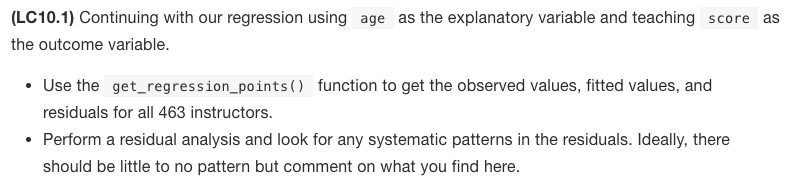

In [28]:
path = '/Users/pdcos/Documents/Estudos/Doutorado/IA376/analise_visual_ciencia_de_dados/participacao_11/evals.rda'
result = read_r(path)
df_evals = result['evals']
df_evals_ch5 = df_evals[['ID', 'score', 'bty_avg', 'age']]


In [29]:
df_evals.head()

,ID,prof_ID,score,age,bty_avg,gender,ethnicity,language,rank,pic_outfit,pic_color,cls_did_eval,cls_students,cls_level
0,1,1,4.7,36,5.0,female,minority,english,tenure track,not formal,color,24,43,upper
1,2,1,4.1,36,5.0,female,minority,english,tenure track,not formal,color,86,125,upper
2,3,1,3.9,36,5.0,female,minority,english,tenure track,not formal,color,76,125,upper
3,4,1,4.8,36,5.0,female,minority,english,tenure track,not formal,color,77,123,upper
4,5,2,4.6,59,3.0,male,not minority,english,tenured,not formal,color,17,20,upper


In [30]:
# Ajustar modelo de regressão com interação entre age e gender
model = smf.ols('score ~ age', data=df_evals_ch5).fit()

# Obter a tabela de coeficientes
regression_table = model.summary().tables[1]

display(regression_table)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,4.4619,0.127,35.195,0.000,4.213,4.711
age,-0.0059,0.003,-2.311,0.021,-0.011,-0.001


In [31]:
# Obter valores ajustados (fitted values) e resíduos (residuals)
df_evals_ch5 = df_evals_ch5.copy()  # Cria uma cópia explícita para evitar o aviso
df_evals_ch5.loc[:,'fitted_values'] = model.fittedvalues
df_evals_ch5.loc[:,'residuals'] = model.resid

# Criar um DataFrame com os pontos de regressão
model_regression_points = df_evals_ch5[['ID', 'score', 'age', 'bty_avg', 'fitted_values','residuals']]
display(model_regression_points.head(10))



,ID,score,age,bty_avg,fitted_values,residuals
0,1,4.7,36,5.000,4.248156,0.451844
1,2,4.1,36,5.000,4.248156,-0.148156
2,3,3.9,36,5.000,4.248156,-0.348156
3,4,4.8,36,5.000,4.248156,0.551844
4,5,4.6,59,3.000,4.111577,0.488423
5,6,4.3,59,3.000,4.111577,0.188423
6,7,2.8,59,3.000,4.111577,-1.311577
7,8,4.1,51,3.333,4.159083,-0.059083
8,9,3.4,51,3.333,4.159083,-0.759083
9,10,4.5,40,3.167,4.224403,0.275597


## Verificando padrões nos resíduos

### Relação entre Score e Age

- O gráfico é um scatterplot que mostra como Score e Age se relacionam no plano cartesiano. De antemão, é possível notar que não existe uma relação linear aparente entre essas duas variáveis, apesar de tere sido usadas no modelo de regressão.

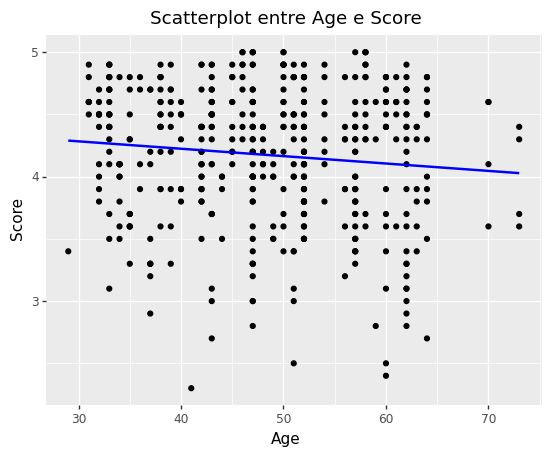

In [32]:
# Printa o scatterplot entre rating e debt

plot = (
    ggplot(df_evals_ch5, aes(x='age', y='score')) +
    geom_point()
    + labs(title='Scatterplot entre Age e Score',
           x='Age',
           y='Score')
    + geom_smooth(method='lm', se=False, color='blue')
)

print(plot)

### Histograma de Resíduos
- Idealmente, o histograma de resíduos deve apresentar um formato de uma distribuição normal. No histograma plotado abaixo, nota-se que o formato não corresponde ao de uma normal, uma vez que não é simétrico.

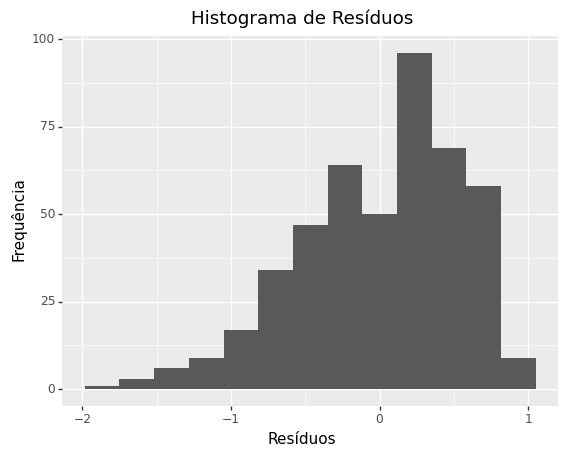

In [33]:
# Plota o histograma de residuos
plot = (
    ggplot(df_evals_ch5, aes(x='residuals')) +
    geom_histogram(bins=13)
    + labs(title='Histograma de Resíduos',
           x='Resíduos',
           y='Frequência')
)
print(plot)

### Variância dos Resíduos
- Para que a regressão seja adequada, é necessário que os resíduos apresentem uma variância que não depende do valor do eixo x. No gráfico abaixo, nota-se que os valores de resíduos para cada valor de Beauty Score aparentam estar dentro da mesma faixa.

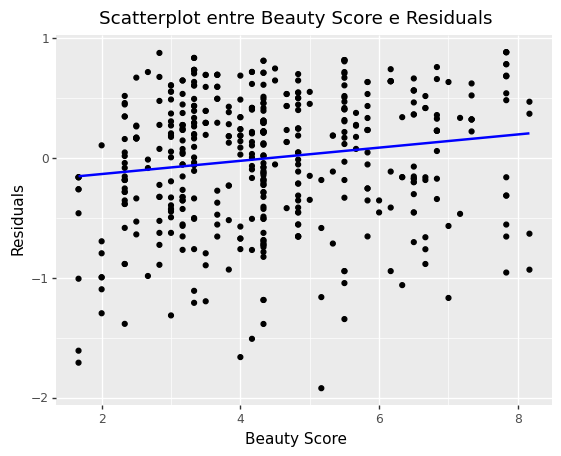

In [39]:
# Printa o scatterplot entre rating e debt



plot = (
    ggplot(model_regression_points, aes(x='bty_avg', y='residuals')) +
    geom_point()
    + labs(title='Scatterplot entre Beauty Score e Residuals',
           x='Beauty Score',
           y='Residuals')
    + geom_smooth(method='lm', se=False, color='blue')
)

print(plot)

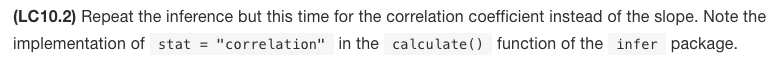

In [42]:


def bootstrap_correlation(df, x, y, reps=1000, seed=76):
    np.random.seed(seed)
    bootstrap_corrs = []
    for _ in range(reps):
        sample = df.sample(frac=1, replace=True)
        corr, _ = stats.pearsonr(sample[x], sample[y])
        bootstrap_corrs.append(corr)
    return bootstrap_corrs

# Load or calculate the bootstrap distribution for correlation
if not os.path.exists("bootstrap_distn_slope.npy"):
    bootstrap_distn_slope = bootstrap_correlation(df_evals_ch5, 'bty_avg', 'score')
    np.save("bootstrap_distn_slope.npy", bootstrap_distn_slope)
else:
    bootstrap_distn_slope = np.load("bootstrap_distn_slope.npy")

# Calculate the observed correlation
observed_corr, _ = stats.pearsonr(df_evals_ch5['bty_avg'], df_evals_ch5['score'])

print(f"Correlação observada: {observed_corr}")


Observed correlation: 0.18714235486847403


# Exercício 2
- Faça os exercícios de aprendizado LC11.1 e LC11.2 relacionados à modelagem de regressão em [34]. Verifique suas respostas no apêndice D do mesmo livro.


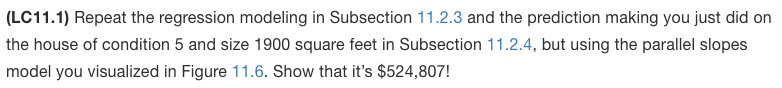

In [46]:
path = '/Users/pdcos/Documents/Estudos/Doutorado/IA376/analise_visual_ciencia_de_dados/participacao_11/house_prices.rda'
result = read_r(path)
print(result.keys())    
df_house_prices = result['house_prices']
df_house_prices.head()

odict_keys(['house_prices'])


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,False,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,False,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,False,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,False,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,False,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [49]:
df_house_prices['log10_price'] = np.log10(df_house_prices['price'])
df_house_prices['log10_size'] = np.log10(df_house_prices['sqft_living'])

model = smf.ols('log10_price ~ log10_size + condition', data=df_house_prices).fit()

# Obter a tabela de coeficientes
regression_table = model.summary().tables[1]

display(regression_table)


,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.8817,0.036,79.994,0.000,2.811,2.952
condition[T.2],-0.0385,0.033,-1.160,0.246,-0.104,0.027
condition[T.3],0.0319,0.031,1.037,0.300,-0.028,0.092
condition[T.4],0.0437,0.031,1.422,0.155,-0.017,0.104
condition[T.5],0.0957,0.031,3.094,0.002,0.035,0.156
log10_size,0.8373,0.006,134.169,0.000,0.825,0.850


In [52]:
# Faz a predicao de uma casa de 1900 sqft com condicao 5
df_pred = pd.DataFrame({'log10_size': [np.log10(1900)], 'condition': ["5"]})
predicted_log10_price = model.predict(df_pred)
predicted_price = 10**predicted_log10_price
print(f"Preço previsto para uma casa de 1900 sqft com condição 5: ${predicted_price[0]:,.2f}")

Preço previsto para uma casa de 1900 sqft com condição 5: $528,012.48


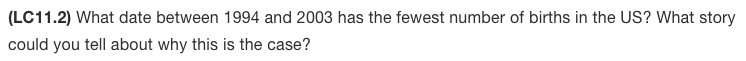

In [53]:
path = '/Users/pdcos/Documents/Estudos/Doutorado/IA376/analise_visual_ciencia_de_dados/participacao_11/US_births_1994-2003_CDC_NCHS.csv'
df_births = pd.read_csv(path)
df_births.head()

,year,month,date_of_month,day_of_week,births
0,1994,1,1,6,8096
1,1994,1,2,7,7772
2,1994,1,3,1,10142
3,1994,1,4,2,11248
4,1994,1,5,3,11053


In [54]:
# Ordena por births
df_births = df_births.sort_values('births')
display(df_births.head(10))

,year,month,date_of_month,day_of_week,births
2915,2001,12,25,2,6443
2550,2000,12,25,1,6566
3645,2003,12,25,4,6628
3280,2002,12,25,3,6629
2184,1999,12,25,6,6674
2549,2000,12,24,7,6801
722,1995,12,24,7,6999
3018,2002,4,7,7,7008
3011,2002,3,31,7,7019
1819,1998,12,25,5,7020


**RESPOSTA:**

A data com menor número de nascimentos é 25/12, que é o Natal. Isso provavelmente ocorre porque existe menos cobertura médica nos hospitais nestes dias, além de ser uma data de comemorativa, em que pessoas preferem passar com a família.